In [1]:

import numpy as np
from keras.datasets import mnist
(X_train_raw, Y_train_raw), (X_test_raw, Y_test_raw) = mnist.load_data()
X_train = X_train_raw.reshape(X_train_raw.shape[0], 28*28) / 255.0
X_test = X_test_raw.reshape(X_test_raw.shape[0], 28*28) / 255.0
def one_hot(Y, num_classes=10):
    one_hot_Y = np.zeros((Y.size, num_classes))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y
Y_train_oh = one_hot(Y_train_raw)
Y_test_oh = one_hot(Y_test_raw)
np.random.seed(42)
W1 = np.random.randn(784, 128) * 0.1
b1 = np.zeros((1, 128))
W2 = np.random.randn(128, 64) * 0.1
b2 = np.zeros((1, 64))
W3 = np.random.randn(64, 10) * 0.1
b3 = np.zeros((1, 10))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
def sigmoid(z):
    z_clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_clipped))
def sigmoid_derivative(a):
    return a * (1.0 - a)

In [3]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

In [4]:
def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

In [5]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]
    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = (A2.T @ delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = (A1.T @ delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (X.T @ delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2, dW3, db3

In [6]:
def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3
    return W1, b1, W2, b2, W3, b3

In [7]:
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []
for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]
    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start : start + batch_size]
        Y_batch = Y_shuf[start : start + batch_size]
        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3)
        W1, b1, W2, b2, W3, b3 = update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate)
    _, _, _, _, _, A3_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

Epoch 1/20 Loss: 0.0627
Epoch 2/20 Loss: 0.0322
Epoch 3/20 Loss: 0.0220
Epoch 4/20 Loss: 0.0180
Epoch 5/20 Loss: 0.0160
Epoch 6/20 Loss: 0.0146
Epoch 7/20 Loss: 0.0136
Epoch 8/20 Loss: 0.0127
Epoch 9/20 Loss: 0.0120
Epoch 10/20 Loss: 0.0113
Epoch 11/20 Loss: 0.0108
Epoch 12/20 Loss: 0.0103
Epoch 13/20 Loss: 0.0099
Epoch 14/20 Loss: 0.0095
Epoch 15/20 Loss: 0.0091
Epoch 16/20 Loss: 0.0087
Epoch 17/20 Loss: 0.0084
Epoch 18/20 Loss: 0.0081
Epoch 19/20 Loss: 0.0079
Epoch 20/20 Loss: 0.0076


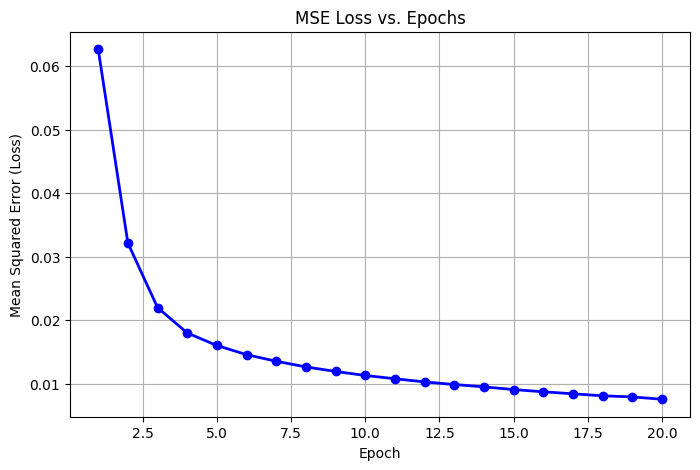

Final Test Accuracy: 95.32%


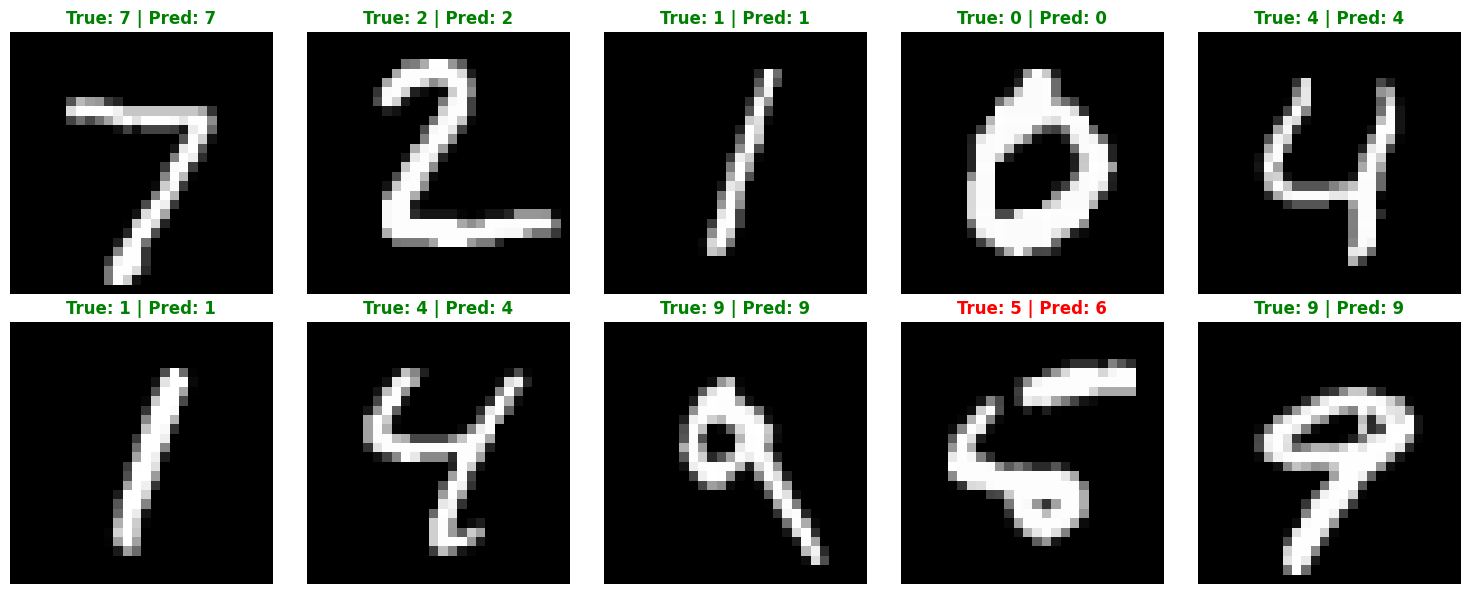

In [8]:
import matplotlib.pyplot as plt
#  LOSS CURVE
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', linewidth=2)
plt.title('MSE Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()
#  TEST ACCURACY
_, _, _, _, _, A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
# Find the highest probability for each prediction
predictions = np.argmax(A3_test, axis=1)
# Calculate percentage correct
accuracy = np.mean(predictions == Y_test_raw) * 100
print(f"Final Test Accuracy: {accuracy:.2f}%")
# 3. SAMPLE PREDICTIONS
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_raw[i], cmap='gray')
    color = 'green' if predictions[i] == Y_test_raw[i] else 'red'
    plt.title(f"True: {Y_test_raw[i]} | Pred: {predictions[i]}", color=color, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()